# Cutting the circle into a one-dimensional transport problem

This notebook generates `fig:monge-circle-cut-unfolding`.  For a Monge cost
$d_{\mathbb S^1}(x,y)^p$ with $p>1$, a correct cut angle unfolds the circle so
that the discrete optimal plan becomes the ordinary monotone matching on an
interval, up to the periodic identification at the cut.


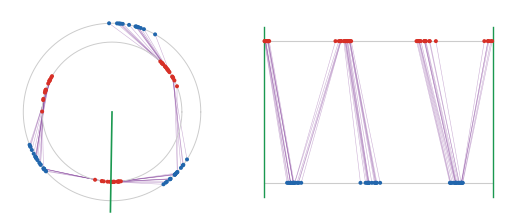

In [1]:

from pathlib import Path
import sys

for candidate in [Path.cwd(), Path.cwd() / "notebooks-figures", Path.cwd().parent / "notebooks-figures"]:
    if (candidate / "figure_style.py").exists():
        sys.path.insert(0, str(candidate.resolve()))
        NOTEBOOK_DIR = candidate.resolve()
        break
else:
    raise RuntimeError("Could not locate figure_style.py")

import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import linear_sum_assignment
from scipy.stats import norm, gaussian_kde
import ot

from figure_style import (
    RED, BLUE, VIOLET, ORANGE, DIRAC_MARKER_SIZE,
    figure_dir, save_pdf, remove_axes, box_axes, setup_matplotlib,
    interp_color, padded_limits,
)

setup_matplotlib()

OUT = figure_dir("monge-circle-cut-unfolding")
THUMB = NOTEBOOK_DIR / "thumbnails" / "monge-circle-cut-unfolding.png"
THUMB.parent.mkdir(exist_ok=True)
rng = np.random.default_rng(42)

source_angles = np.concatenate([
    rng.normal(0.65, 0.14, 21),
    rng.normal(2.75, 0.18, 15),
    rng.normal(4.70, 0.16, 18),
]) % (2 * np.pi)
target_angles = np.concatenate([
    rng.normal(1.35, 0.17, 15),
    rng.normal(3.75, 0.18, 21),
    rng.normal(5.55, 0.13, 18),
]) % (2 * np.pi)
n = len(source_angles)


def unwrap(theta, cut):
    return (theta - cut) % (2 * np.pi)


def circle_distance(a, b):
    d = np.abs(a - b) % (2 * np.pi)
    return np.minimum(d, 2 * np.pi - d)

cuts = np.sort(np.concatenate([source_angles, target_angles]))
candidates = (cuts + np.roll(cuts, -1)) / 2
# Correct the candidate crossing zero.
candidates[-1] = ((cuts[-1] + cuts[0] + 2 * np.pi) / 2) % (2 * np.pi)

best = None
for cut in candidates:
    xs = unwrap(source_angles, cut)
    ys = unwrap(target_angles, cut)
    si = np.argsort(xs)
    tj = np.argsort(ys)
    cost = np.sum(circle_distance(source_angles[si], target_angles[tj]) ** 2)
    if best is None or cost < best[0]:
        best = (cost, cut, si, tj, xs, ys)
_, cut, si, tj, xs, ys = best
pairs = list(zip(si, tj))


def point(angle, radius):
    return np.array([radius * np.cos(angle), radius * np.sin(angle)])


def draw_circle(ax):
    t = np.linspace(0, 2 * np.pi, 400)
    ax.plot(np.cos(t), np.sin(t), color="#cccccc", lw=0.7)
    ax.plot(1.27 * np.cos(t), 1.27 * np.sin(t), color="#cccccc", lw=0.7)
    for i, j in pairs:
        a = point(source_angles[i], 1.0)
        b = point(target_angles[j], 1.27)
        ax.plot([a[0], b[0]], [a[1], b[1]], color=VIOLET, lw=0.38, alpha=0.40, zorder=1)
    ax.scatter(np.cos(source_angles), np.sin(source_angles), s=0.55 * DIRAC_MARKER_SIZE, color=RED, edgecolor="none", zorder=3)
    ax.scatter(1.27 * np.cos(target_angles), 1.27 * np.sin(target_angles), s=0.55 * DIRAC_MARKER_SIZE, color=BLUE, edgecolor="none", zorder=3)
    ax.plot([0, 1.43 * np.cos(cut)], [0, 1.43 * np.sin(cut)], color="#1a9850", lw=1.2, zorder=4)
    ax.set_aspect("equal")
    ax.set_xlim(-1.46, 1.46)
    ax.set_ylim(-1.46, 1.46)
    remove_axes(ax)


def draw_unfolded(ax):
    xs_un = unwrap(source_angles, cut)
    ys_un = unwrap(target_angles, cut)
    for i, j in pairs:
        ax.plot([xs_un[i], ys_un[j]], [1.0, 0.0], color=VIOLET, lw=0.38, alpha=0.40, zorder=1)
    ax.plot([0, 2 * np.pi], [1, 1], color="#cccccc", lw=0.8, zorder=0)
    ax.plot([0, 2 * np.pi], [0, 0], color="#cccccc", lw=0.8, zorder=0)
    for x0 in [0, 2 * np.pi]:
        ax.plot([x0, x0], [-0.10, 1.10], color="#1a9850", lw=1.0, zorder=2)
    ax.scatter(xs_un, np.ones(n), s=0.55 * DIRAC_MARKER_SIZE, color=RED, edgecolor="none", zorder=3)
    ax.scatter(ys_un, np.zeros(n), s=0.55 * DIRAC_MARKER_SIZE, color=BLUE, edgecolor="none", zorder=3)
    ax.set_xlim(-0.12, 2 * np.pi + 0.12)
    ax.set_ylim(-0.22, 1.22)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

fig, axs = plt.subplots(1, 2, figsize=(6.3, 2.65), gridspec_kw={"width_ratios": [1, 1.15]})
draw_circle(axs[0])
draw_unfolded(axs[1])
for name, drawer, size in [("circle", draw_circle, (2.55, 2.55)), ("unfolded", draw_unfolded, (3.0, 1.65))]:
    single, ax = plt.subplots(figsize=size)
    drawer(ax)
    save_pdf(single, OUT / f"{name}.pdf", pad_inches=0.035)
    plt.close(single)
fig.savefig(THUMB, dpi=220, bbox_inches="tight", pad_inches=0.04)
plt.show()
